# Problem description
The state variables are        $
x = \begin{bmatrix}x\\ y\\ \phi \\ \theta \end{bmatrix}
$ $\quad$
$
u = \begin{bmatrix}v_x\\ \omega \\ v \end{bmatrix}
$

$$
\dot{x} = \begin{bmatrix}v_x\cos\phi \\ v_x\sin\phi \\ \omega \\ v \end{bmatrix}
$$

The path will be parametized by $\begin{bmatrix} x_d(\theta) \\ y_d(\theta) \end{bmatrix}$

We define the path parameter $\theta$ and corresponding path points:
- $x_d(\theta)$ = spline-interpolated x-coordinate  
- $y_d(\theta)$ = spline-interpolated y-coordinate
- $\phi(\theta) = \arctan\left(\frac{y_d'(\theta)}{x_d'(\theta)}\right)$ (path tangent angle)

The contouring and lag errors are:
- $\varepsilon_c = \sin(\phi(\theta))(x - x_d(\theta)) - \cos(\phi(\theta))(y - y_d(\theta))$ (perpendicular to path)
- $\varepsilon_l = -\cos(\phi(\theta))(x - x_d(\theta)) - \sin(\phi(\theta))(y - y_d(\theta))$ (along path direction)

We want to minimize:
$$
q_c\varepsilon_c^2 + q_l\varepsilon_l^2 - q_\theta\theta + \mathbf{u}^T\mathbf{Q}\mathbf{u}
$$

where $\theta$ is now an optimization variable representing progress along the waypoint sequence.

## Problems

1. If I don't set a limit for v(how fast can theta be changed), the controller try to cheat by commanding a high v to just get the progress reward early on. This is problematic if we want to make the robot follow overlapping circles as it will just want to cheat by jumping the progress and ending the path early

In [323]:
# Import necessary libraries
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import FancyArrow, Circle

In [324]:
# Dynamics and integration
# Dynamics definition

# States
x = ca.MX.sym('x') # type: ignore
y = ca.MX.sym('y') # type: ignore
phi = ca.MX.sym('phi') # type: ignore
theta = ca.MX.sym('theta') # type: ignore

# Inputs
v_x = ca.MX.sym('v_x') # type: ignore
omega = ca.MX.sym('omega') # type: ignore
v = ca.MX.sym('v') # type: ignore

state = ca.vertcat(x, y, phi, theta)
control = ca.vertcat(v_x, omega, v)

ode = ca.vertcat(
    v_x * ca.cos(phi),  # x_dot
    v_x * ca.sin(phi),  # y_dot  
    omega,              # phi_dot
    v,                  # virtual_speed
)

# Dynamics defined
f = ca.Function('f', [state, control], [ode], ['x', 'u'], ['ode'])

f

Function(f:(x[4],u[3])->(ode[4]) MXFunction)

## Use RK4 To discretize the system dynamics

In [325]:
N = 10  # Prediction horizon (number of time steps)
T = 0.05  # Sampling time
# Integrator options
intg_options = {
    'simplify': True,
    'number_of_finite_elements': 4
}

dae = {
    'x': state,      # What are states?
    'p': control,      # What are parameters (fixed during integration horizon)?
    'ode': f(state, control)   # Expression for the right-hand side
}
# integrator(str name, str solver, Function dae, float t0, [float] tout, dict opts) -> Function
intg = ca.integrator('intg', 'rk', dae, 0, N*T, intg_options)
x_next = intg(x0=state, p=control)['xf']

# Big F, the discretized function
F = ca.Function('F', [state, control], [x_next], ['x', 'u'], ['x_next'])
f

Function(f:(x[4],u[3])->(ode[4]) MXFunction)

In [326]:
sim = F.mapaccum(N)
sim

Function(F_acc10:(x[4],u[3x10])->(x_next[4x10]) MXFunction)

In [327]:

U = ca.MX.sym('U', 3, N) # type: ignore
U

MX(U)

# Solve for problem

## Define path

Testing spiral path functions...
s	 x_d	 y_d	 phi_path
----------------------------------------
0.0	5.00	0.00	1.518
0.1	-1.70	5.23	-2.876
0.2	-4.85	-3.53	-0.987
0.3	5.26	-3.82	0.902
0.4	2.16	6.66	2.790
0.5	-7.50	0.00	-1.606
0.6	2.47	-7.61	0.281
0.7	6.88	5.00	2.168
0.8	-7.28	5.29	-2.229
0.9	-2.94	-9.04	-0.342
1.0	10.00	-0.00	1.544


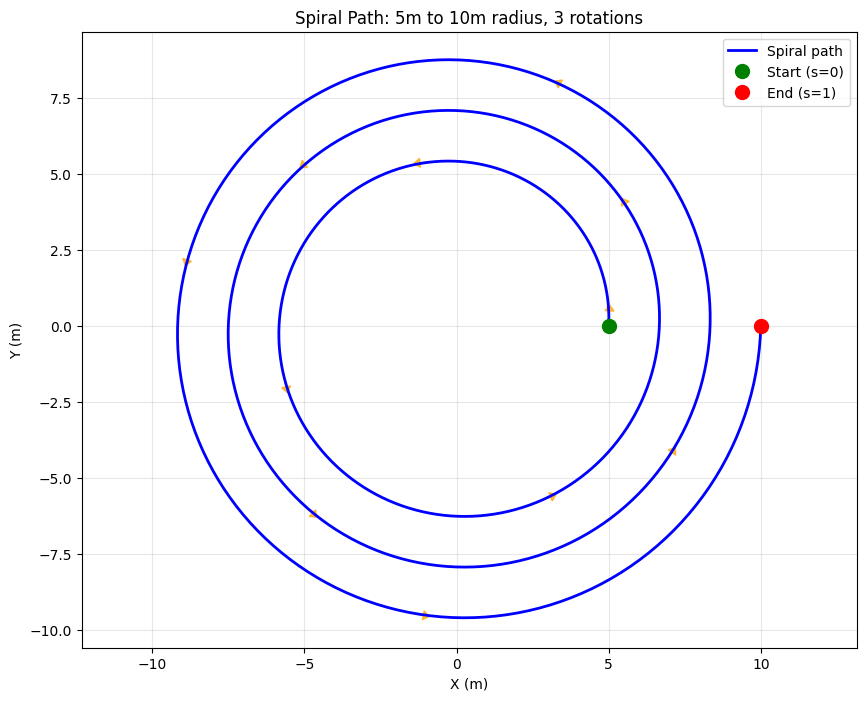


Testing error computation...
Test successful: eps_c = -7.4979, eps_l = -5.6872

Testing derivative continuity...
  At s=0.113, jump = 5.309 rad
  At s=0.423, jump = 5.310 rad
  At s=0.784, jump = 5.310 rad

Spiral path successfully created!
- Starts at radius 5.0m, ends at radius 10.0m
- 3 full rotations
- Parameter s ∈ [0, 1] maps to θ ∈ [0, 18.8] rad


In [328]:
# Define spiral parameters
r_start = 5.0    # Starting radius (m)
r_end = 10.0     # Ending radius (m)
n_rotations = 3  # Number of full rotations
theta_end = 2 * np.pi * n_rotations  # Total angle

# Create spiral path functions
def create_spiral_path():
    """Create CasADi functions for spiral path"""
    
    # Symbolic parameter (normalized 0 to 1)
    s = ca.MX.sym('s')
    
    # Convert normalized parameter to actual angle
    theta_actual = s * theta_end
    
    # Radius grows linearly from r_start to r_end
    radius = r_start + (r_end - r_start) * s
    
    # Spiral coordinates
    x_spiral = radius * ca.cos(theta_actual)
    y_spiral = radius * ca.sin(theta_actual)
    
    # Create CasADi functions
    x_d = ca.Function('x_d', [s], [x_spiral])
    y_d = ca.Function('y_d', [s], [y_spiral])
    
    # Compute derivatives for tangent angle
    dx_ds = ca.jacobian(x_spiral, s)
    dy_ds = ca.jacobian(y_spiral, s)
    
    # Tangent angle function
    phi_path = ca.Function('phi_path', [s], [ca.atan2(dy_ds, dx_ds)])
    
    return x_d, y_d, phi_path

# Create the path functions
x_d, y_d, phi_path = create_spiral_path()

# Test the functions
print("Testing spiral path functions...")
test_params = np.linspace(0, 1, 11)

print("s\t x_d\t y_d\t phi_path")
print("-" * 40)
for s in test_params:
    try:
        x_val = float(x_d(s))
        y_val = float(y_d(s))
        phi_val = float(phi_path(s))
        print(f"{s:.1f}\t{x_val:.2f}\t{y_val:.2f}\t{phi_val:.3f}")
    except Exception as e:
        print(f"ERROR at s={s}: {e}")

# Visualize the spiral path
s_plot = np.linspace(0, 1, 500)
x_plot = [float(x_d(s)) for s in s_plot]
y_plot = [float(y_d(s)) for s in s_plot]

plt.figure(figsize=(10, 8))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='Spiral path')
plt.plot(x_plot[0], y_plot[0], 'go', markersize=10, label='Start (s=0)')
plt.plot(x_plot[-1], y_plot[-1], 'ro', markersize=10, label='End (s=1)')

# Add direction arrows
arrow_indices = np.linspace(0, len(s_plot)-1, 12, dtype=int)
for i in arrow_indices[:-1]:  # Skip last point
    s_val = s_plot[i]
    phi_val = float(phi_path(s_val))
    dx = 0.5 * np.cos(phi_val)
    dy = 0.5 * np.sin(phi_val)
    plt.arrow(x_plot[i], y_plot[i], dx, dy, 
              head_width=0.3, head_length=0.2, 
              fc='orange', ec='orange', alpha=0.7)

plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Spiral Path: 5m to 10m radius, 3 rotations')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')
plt.show()

# Define error functions
def compute_errors(x_robot, y_robot, s_param):
    """Compute contouring and lag errors for spiral path"""
    x_path = x_d(s_param)
    y_path = y_d(s_param)
    tangent_angle = phi_path(s_param)
    
    # Contouring error (perpendicular to path)
    eps_c = ca.sin(tangent_angle) * (x_robot - x_path) - ca.cos(tangent_angle) * (y_robot - y_path)
    
    # Lag error (along path direction)
    eps_l = -ca.cos(tangent_angle) * (x_robot - x_path) - ca.sin(tangent_angle) * (y_robot - y_path)
    
    return eps_c, eps_l

# Test error computation
print("\nTesting error computation...")
try:
    eps_c, eps_l = compute_errors(6.0, 1.0, 0.25)  # Test point
    print(f"Test successful: eps_c = {float(eps_c):.4f}, eps_l = {float(eps_l):.4f}")
except Exception as e:
    print(f"Error computation failed: {e}")

# Test derivative continuity
print("\nTesting derivative continuity...")
s_test = np.linspace(0.01, 0.99, 20)
prev_phi = None
large_jumps = []

for s in s_test:
    phi_val = float(phi_path(s))
    if prev_phi is not None:
        jump = abs(phi_val - prev_phi)
        if jump > 3.0:  # Large jump (might indicate discontinuity)
            large_jumps.append((s, jump))
    prev_phi = phi_val

if large_jumps:
    print("WARNING: Large tangent angle jumps detected:")
    for s, jump in large_jumps:
        print(f"  At s={s:.3f}, jump = {jump:.3f} rad")
else:
    print("Tangent angle appears continuous.")

print(f"\nSpiral path successfully created!")
print(f"- Starts at radius {r_start}m, ends at radius {r_end}m")
print(f"- {n_rotations} full rotations")
print(f"- Parameter s ∈ [0, 1] maps to θ ∈ [0, {theta_end:.1f}] rad")

In [329]:
compute_errors(1,1,1)

(DM(-9.02335), DM(-0.761))

In [343]:
opti = ca.Opti()

x = opti.variable(4, N+1) # type: ignore
u = opti.variable(3, N) # type: ignore
p = opti.parameter(4, 1) # type: ignore

# Cost function with MPCC errors
q_c = 100    # contouring error weight
q_l = 10   # lag error weight  
q_theta = 100  # progress weight
R = ca.diag([1, 1, 1000])  # control weights

for k in range(N):
    opti.subject_to(x[:, k+1] == F(x[:, k], u[:, k]))

cost = 0
for k in range(N):
    # Compute errors at each prediction step
    eps_c, eps_l = compute_errors(x[0,k], x[1,k], x[3,k])
    # MPCC cost
    cost += q_c * eps_c**2 + q_l * eps_l**2 - q_theta * x[3,k]
    cost += ca.mtimes([u[:,k].T, R, u[:,k]])

opti.minimize(cost)

opti.subject_to(x[:,0] == p)

# Set speed limit
opti.subject_to(u[0, :] <= 8)
opti.subject_to(u[0, :] >= 0)
opti.subject_to(u[1, :] <= 1)
opti.subject_to(u[1, :] >= -1)
opti.subject_to(u[2, :] > 0)
opti.subject_to(u[2, :] < 0.05)

# Theta limit
opti.subject_to(x[3, :] <= 1)
opti.subject_to(x[3, :] >= 0)

# Set initial condition
opti.subject_to(x[:,0] == p)
# opti.solver('worhp')
# opti.solver('sqpmethod')
opts = {
    'ipopt': {
        'print_level': 0,  # Just suppress output
        'sb': 'yes',
        'warm_start_init_point': 'yes',
    },
    'print_time': True
}
opti.solver('ipopt')
opti.set_value(p, ca.vertcat(0, 0, 0, 0))
sol = opti.solve()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      168
Number of nonzeros in inequality constraint Jacobian.:       82
Number of nonzeros in Lagrangian Hessian.............:      130

Total number of variables............................:       74
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       48
Total number of inequality constraints...............:       82
        inequality constraints with only lower bounds:       41
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       41

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.4936852e+04 0.00e+00 1.00e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

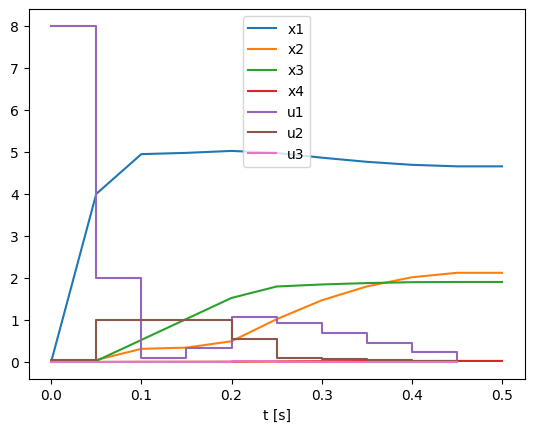

In [344]:
# Extract values from CasADi solution
x_vals = sol.value(x)  # Shape: (4, N) for 4 states
u_vals = sol.value(u)  # Shape: (3, N) for 3 inputs

tgrid = np.linspace(0, T*N, N+1)
plt.figure()
# Plot 3 states
plt.plot(tgrid, x_vals[0, :], label='x')
plt.plot(tgrid, x_vals[1, :], label='y') 
plt.plot(tgrid, x_vals[2, :], label='theta')
plt.plot(tgrid, x_vals[3, :], label='s')

# Plot 2 inputs as steps
plt.step(tgrid[:-1], u_vals[0, :], where='post', label='u1')
plt.step(tgrid[:-1], u_vals[1, :], where='post', label='u2')
plt.step(tgrid[:-1], u_vals[2, :], where='post', label='u3')

plt.xlabel('t [s]')
plt.legend(['x1', 'x2', 'x3','x4', 'u1', 'u2','u3'])

(np.float64(-0.2512024667482026),
 np.float64(5.275251801712256),
 np.float64(-0.10610916250106751),
 np.float64(2.2282924125224177))

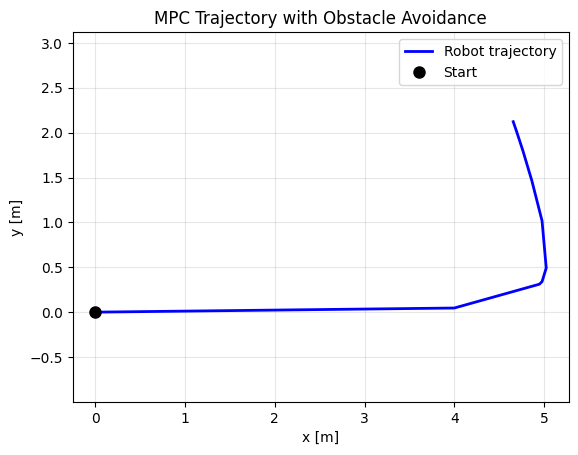

In [345]:
plt.figure()
plt.plot(x_vals[0, :], x_vals[1, :], 'b-', linewidth=2, label='Robot trajectory')

# Add start point
plt.plot(x_vals[0, 0], x_vals[1, 0], 'ko', markersize=8, label='Start')

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('MPC Trajectory with Obstacle Avoidance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

In [346]:
M = opti.to_function('M',[p],[u[:,0]],['p'],['u_opt'])
M

Function(M:(p[4])->(u_opt[3]) MXFunction)

In [349]:
x_log = []
u_log = []

x = ca.vertcat(0, 0, 0, 0)


while(True):
    u = M(x)
    x_log.append(x)
    u_log.append(u)
    x = F(x, u)
    if (1 - x[3] < 0.001):
        break

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      168
Number of nonzeros in inequality constraint Jacobian.:       82
Number of nonzeros in Lagrangian Hessian.............:      130

Total number of variables............................:       74
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       48
Total number of inequality constraints...............:       82
        inequality constraints with only lower bounds:       41
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       41

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.4936852e+04 0.00e+00 1.00e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

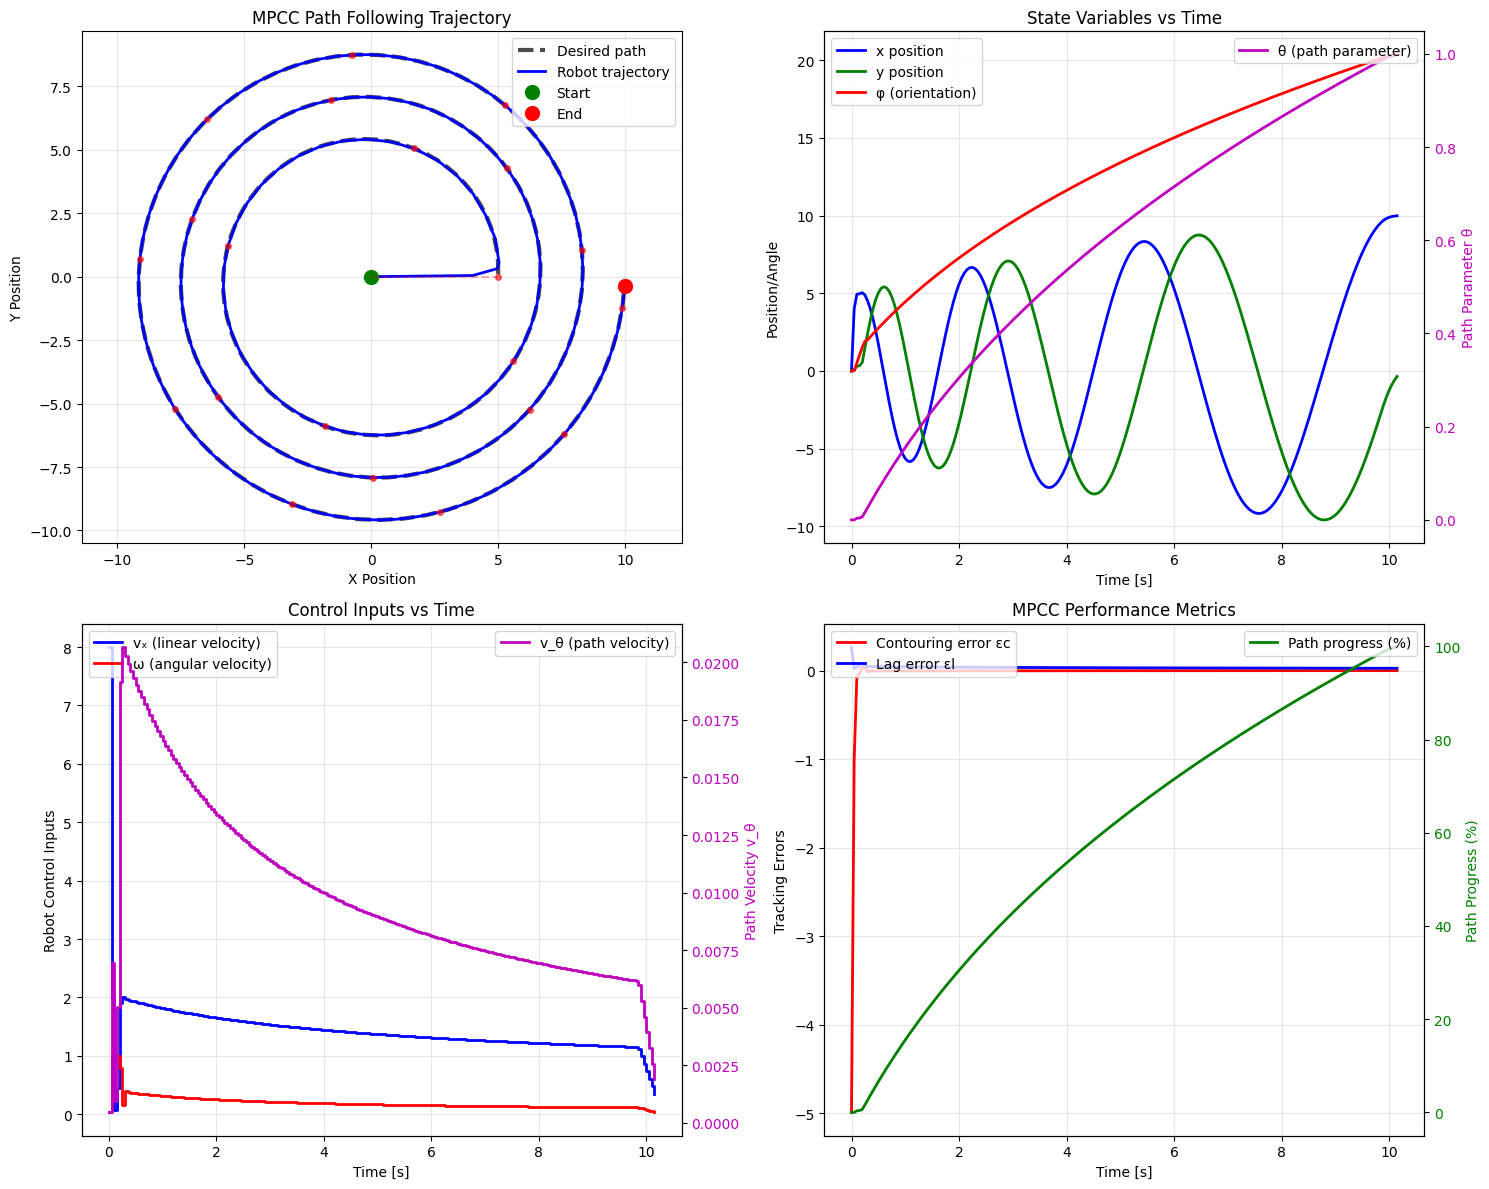

MPCC Simulation completed:
- Duration: 10.2 seconds
- Final position: (9.98, -0.35)
- Path progress: 99.8% (θ = 0.998)
- Final orientation: 20.358 rad (1166.4°)
- Average contouring error: 0.0326
- Max contouring error: 4.9930
- Average lag error: 0.0338
- Average path velocity: 0.0098


In [350]:
# Convert CasADi arrays to numpy for plotting
from matplotlib import patches

x_traj = np.array([np.array(x).flatten() for x in x_log])  # Shape: (N, 4) - now includes theta
u_traj = np.array([np.array(u).flatten() for u in u_log])  # Shape: (N, 3) - now includes v_theta

# Time vector
time_steps = np.arange(len(x_log)) * T

# Generate reference path for plotting
theta_ref = np.linspace(0.001, 0.999, 200)
x_ref_path = [float(x_d(t)) for t in theta_ref]
y_ref_path = [float(y_d(t)) for t in theta_ref]

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Trajectory in 2D space with path following
ax1.plot(x_ref_path, y_ref_path, 'k--', linewidth=3, label='Desired path', alpha=0.7)
ax1.plot(x_traj[:, 0], x_traj[:, 1], 'b-', linewidth=2, label='Robot trajectory')
ax1.plot(x_traj[0, 0], x_traj[0, 1], 'go', markersize=10, label='Start')
ax1.plot(x_traj[-1, 0], x_traj[-1, 1], 'ro', markersize=10, label='End')

# Show current path target points
target_interval = max(1, len(x_traj) // 20)
for i in range(0, len(x_traj), target_interval):
   theta_current = x_traj[i, 3]  # Current theta value
   x_target = float(x_d(theta_current))
   y_target = float(y_d(theta_current))
   ax1.plot(x_target, y_target, 'ro', markersize=4, alpha=0.6)
   ax1.plot([x_traj[i, 0], x_target], [x_traj[i, 1], y_target], 'r--', alpha=0.3)

# Add orientation arrows at regular intervals
arrow_interval = max(1, len(x_traj) // 10)
for i in range(0, len(x_traj), arrow_interval):
   x, y, phi = x_traj[i, :3]
   dx = 0.3 * np.cos(phi)
   dy = 0.3 * np.sin(phi)
   ax1.arrow(x, y, dx, dy, head_width=0.1, head_length=0.05, 
             fc='orange', ec='orange', alpha=0.7)

ax1.set_xlabel('X Position')
ax1.set_ylabel('Y Position')
ax1.set_title('MPCC Path Following Trajectory')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axis('equal')

# 2. State variables over time (including theta)
ax2.plot(time_steps, x_traj[:, 0], 'b-', linewidth=2, label='x position')
ax2.plot(time_steps, x_traj[:, 1], 'g-', linewidth=2, label='y position')
ax2.plot(time_steps, x_traj[:, 2], 'r-', linewidth=2, label='φ (orientation)')
ax2_twin = ax2.twinx()
ax2_twin.plot(time_steps, x_traj[:, 3], 'm-', linewidth=2, label='θ (path parameter)')
ax2_twin.set_ylabel('Path Parameter θ', color='m')
ax2_twin.tick_params(axis='y', labelcolor='m')

ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Position/Angle')
ax2.set_title('State Variables vs Time')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# 3. Control inputs over time (including v_theta)
ax3.step(time_steps, u_traj[:, 0], 'b-', linewidth=2, where='post', label='vₓ (linear velocity)')
ax3.step(time_steps, u_traj[:, 1], 'r-', linewidth=2, where='post', label='ω (angular velocity)')
ax3_twin = ax3.twinx()
ax3_twin.step(time_steps, u_traj[:, 2], 'm-', linewidth=2, where='post', label='v_θ (path velocity)')
ax3_twin.set_ylabel('Path Velocity v_θ', color='m')
ax3_twin.tick_params(axis='y', labelcolor='m')

ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Robot Control Inputs')
ax3.set_title('Control Inputs vs Time')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# 4. MPCC-specific metrics
# Compute contouring and lag errors
eps_c_values = []
eps_l_values = []
path_progress = []

for i in range(len(x_traj)):
   x_pos, y_pos, phi_robot, theta_val = x_traj[i]
   
   # Compute errors
   try:
       eps_c, eps_l = compute_errors(x_pos, y_pos, theta_val)
       eps_c_values.append(float(eps_c))
       eps_l_values.append(float(eps_l))
       path_progress.append(theta_val * 100)  # Convert to percentage
   except:
       eps_c_values.append(np.nan)
       eps_l_values.append(np.nan)
       path_progress.append(theta_val * 100)

ax4.plot(time_steps, eps_c_values, 'r-', linewidth=2, label='Contouring error εc')
ax4.plot(time_steps, eps_l_values, 'b-', linewidth=2, label='Lag error εl')
ax4_twin = ax4.twinx()
ax4_twin.plot(time_steps, path_progress, 'g-', linewidth=2, label='Path progress (%)')
ax4_twin.set_ylabel('Path Progress (%)', color='g')
ax4_twin.tick_params(axis='y', labelcolor='g')

ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Tracking Errors')
ax4.set_title('MPCC Performance Metrics')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print MPCC-specific statistics
print(f"MPCC Simulation completed:")
print(f"- Duration: {time_steps[-1]:.1f} seconds")
print(f"- Final position: ({x_traj[-1, 0]:.2f}, {x_traj[-1, 1]:.2f})")
print(f"- Path progress: {x_traj[-1, 3]*100:.1f}% (θ = {x_traj[-1, 3]:.3f})")
print(f"- Final orientation: {x_traj[-1, 2]:.3f} rad ({np.degrees(x_traj[-1, 2]):.1f}°)")
print(f"- Average contouring error: {np.nanmean(np.abs(eps_c_values)):.4f}")
print(f"- Max contouring error: {np.nanmax(np.abs(eps_c_values)):.4f}")
print(f"- Average lag error: {np.nanmean(np.abs(eps_l_values)):.4f}")
print(f"- Average path velocity: {np.mean(u_traj[:, 2]):.4f}")